In [2]:
import pandas as pd

data = pd.read_csv('./data/clean/RO_data.csv')
data["Date"] = pd.to_datetime(data["Date"])
data["delta P"] = data["ALIMENTATION - Pression HP (bar)"] - data["PERMEAT - Pression Sortie (bar)"]
data["Performance Débit"] = data["PERMEAT - Débit (m3/h)"] * 100/ (data["ALIMENTATION - Débit (m3/h) PX"] + data["ALIMENTATION - Débit (m3/h)"])

avg_data = data.drop(columns=["Rack"]).groupby("Date").mean()

# data.index = data["Date"]
avg_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 261 entries, 2024-02-19 to 2025-01-28
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ALIMENTATION - Débit (m3/h)       256 non-null    float64
 1   ALIMENTATION - Débit (m3/h) PX    256 non-null    float64
 2   ALIMENTATION - Pression HP (bar)  256 non-null    float64
 3   PERMEAT - Conductivité (µS/cm)    256 non-null    float64
 4   PERMEAT - Débit (m3/h)            256 non-null    float64
 5   PERMEAT - Pression Sortie (bar)   256 non-null    float64
 6   delta P                           256 non-null    float64
 7   Performance Débit                 256 non-null    float64
dtypes: float64(8)
memory usage: 18.4 KB


In [4]:
avg_data.to_csv('./data/clean/RO_data_aggregated.csv')

In [9]:
agg_data

,Date,ALIMENTATION - Débit (m3/h),ALIMENTATION - Débit (m3/h) PX,ALIMENTATION - Pression HP (bar),PERMEAT - Conductivité (µS/cm),PERMEAT - Débit (m3/h),PERMEAT - Pression Sortie (bar),delta P,Performance Débit
0,2024-02-19,522.6700,424.2750,61.8275,201.250,419.8075,60.7850,1.0425,44.332827
1,2024-02-20,522.5700,423.9950,61.8225,200.175,419.5825,60.7950,1.0275,44.326824
2,2024-02-21,522.3600,426.6300,61.4800,209.500,424.0400,60.4450,1.0350,44.683331
3,2024-02-22,522.6675,423.7475,61.6850,202.900,419.5400,60.6550,1.0300,44.329343
4,2024-02-24,522.1450,424.8750,61.6625,202.750,419.6500,60.7350,0.9275,44.312912
...,...,...,...,...,...,...,...,...,...
256,2025-01-23,520.2500,422.7500,61.5325,267.000,418.2500,60.3400,1.1925,44.353452
257,2025-01-25,521.0000,421.5000,61.6125,270.750,417.0000,60.4150,1.1975,44.244225
258,2025-01-26,520.2500,421.5000,61.6125,270.750,417.0000,60.4150,1.1975,44.279352
259,2025-01-27,520.2500,421.5000,61.6125,270.750,417.0000,60.4150,1.1975,44.279352


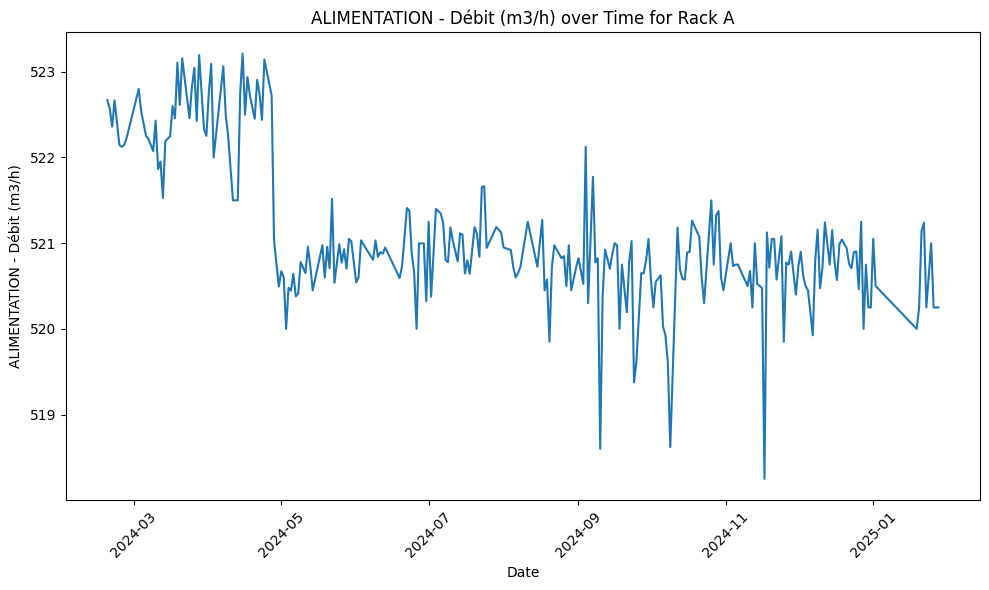

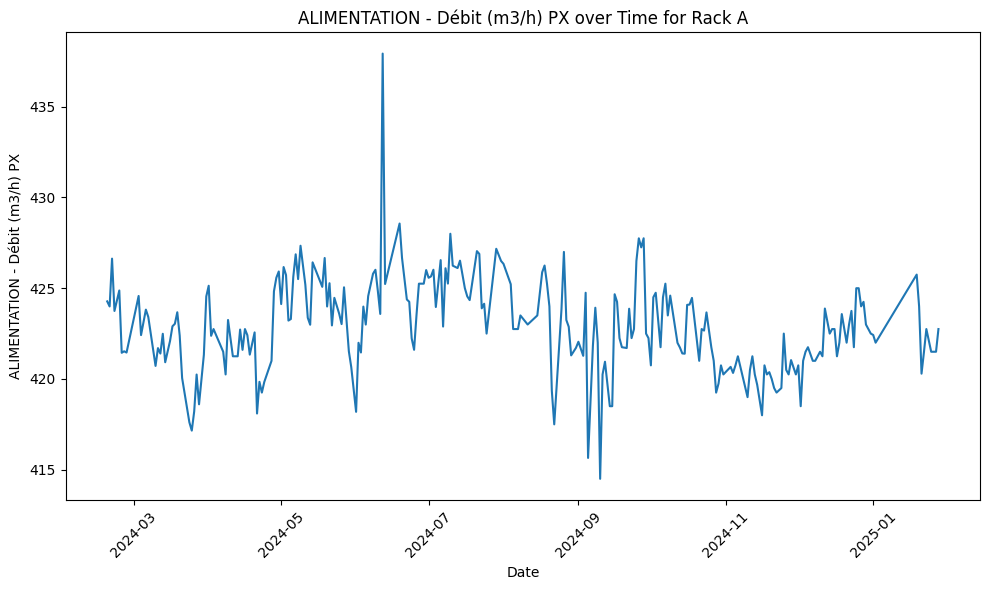

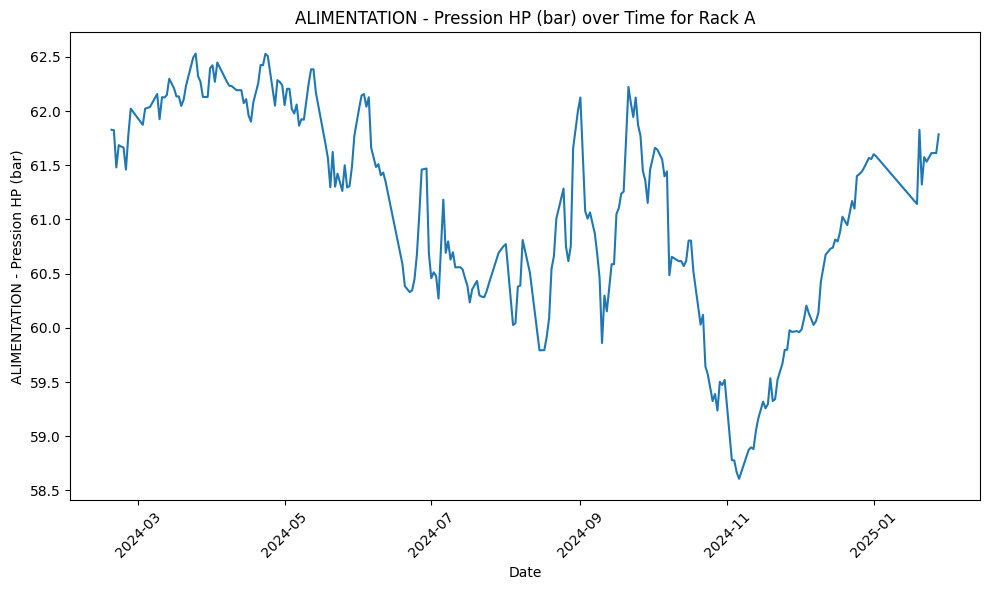

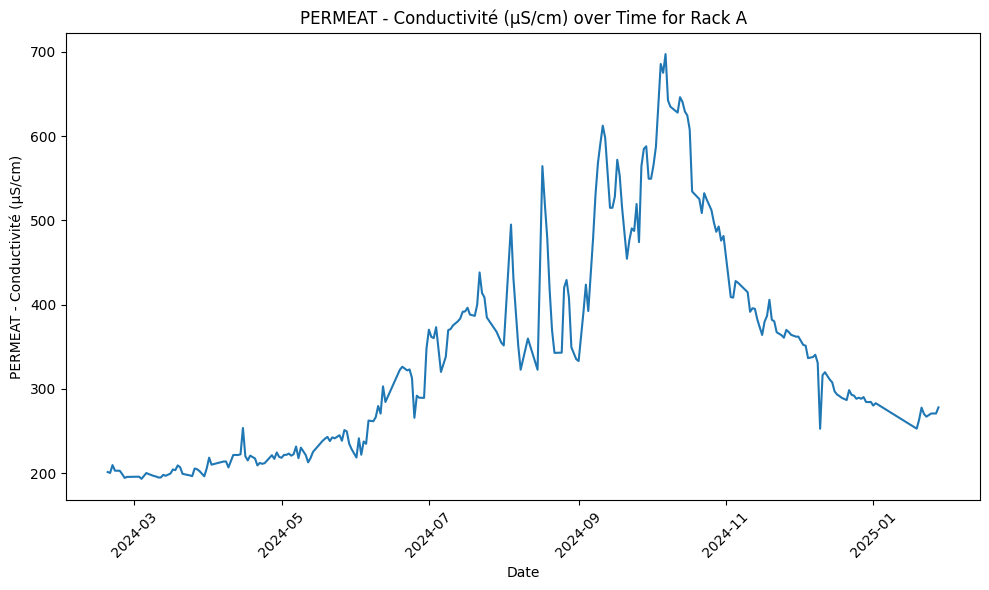

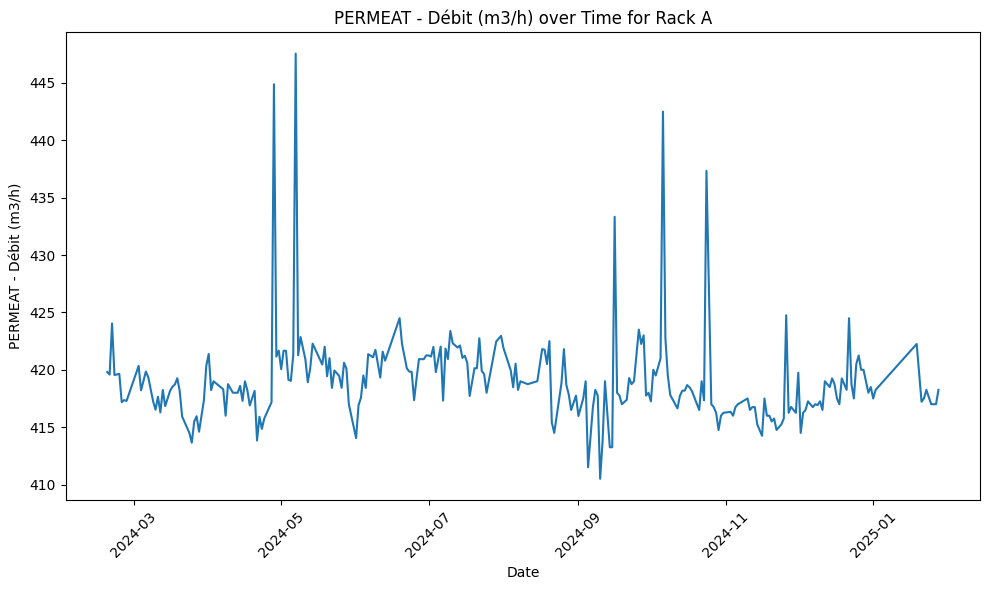

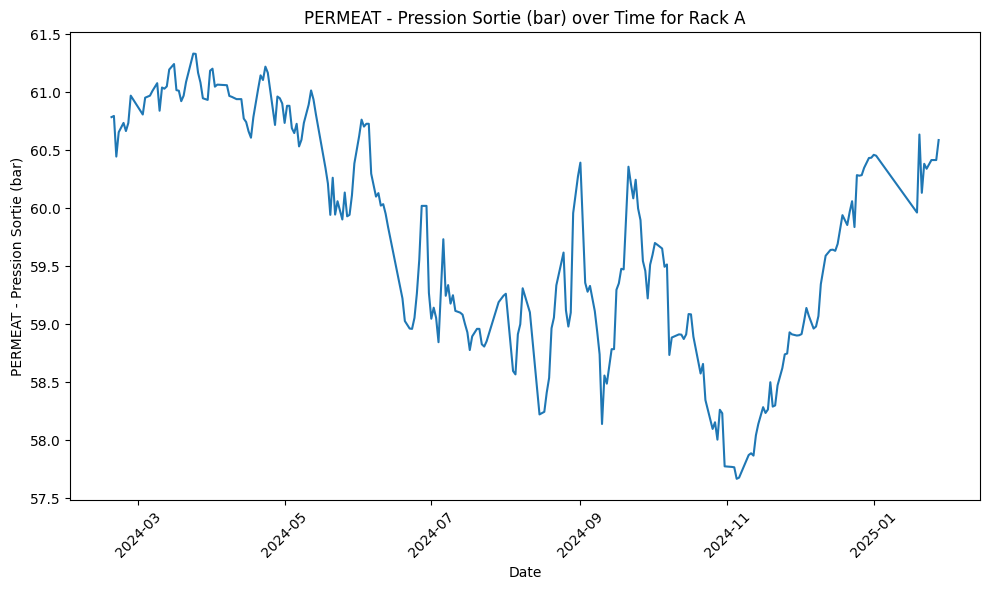

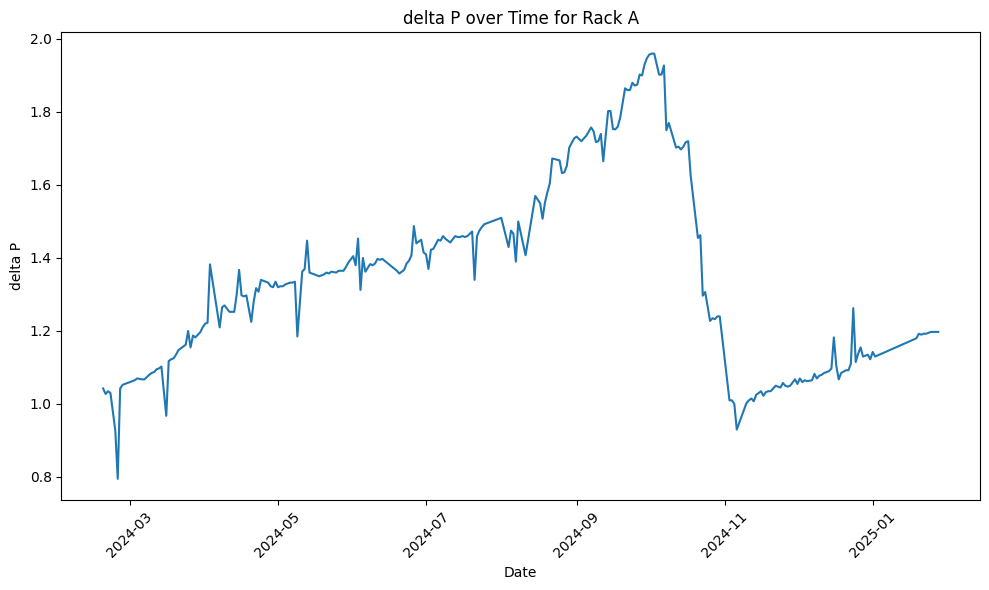

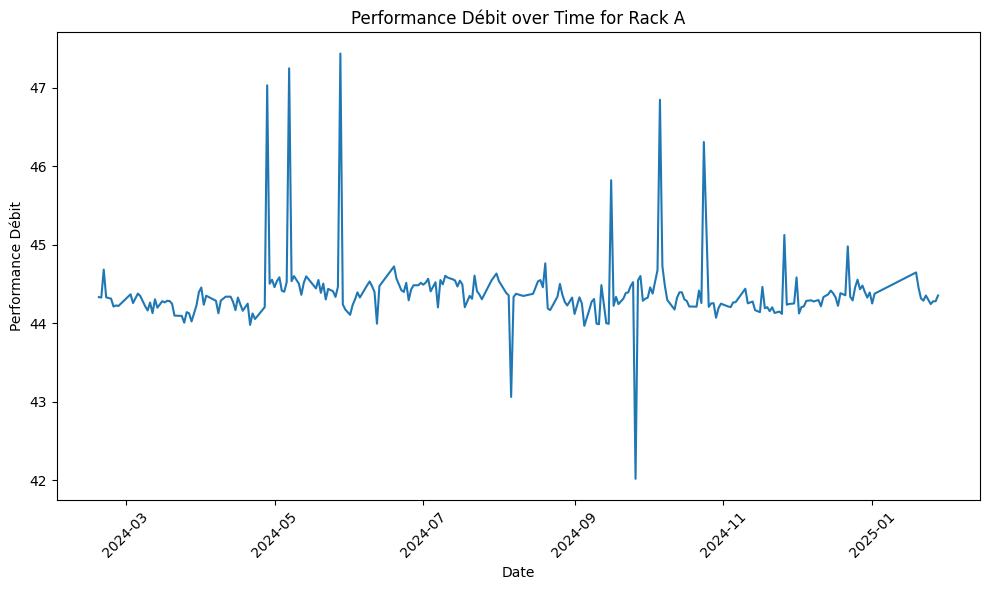

In [16]:
# build plots for aggregated data
import pandas as pd
agg_data = pd.read_csv('./data/clean/RO_data_aggregated.csv')
agg_data["Date"] = pd.to_datetime(agg_data["Date"])

import matplotlib.pyplot as plt
import seaborn as sns

for col in agg_data.columns:
    if col != 'Date':
        plt.figure(figsize=(10, 6))
        sns.lineplot(x='Date', y=col, data=agg_data)
        plt.title(f'{col} over Time for Rack A')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()